<div>
  <img style="width:100%" src="https://capsule-render.vercel.app/api?type=waving&height=100&section=header&fontSize=70&fontColor=FFFFFF&color=87CEEB" />
</div>

# **House Prices – Advanced Regression Techniques**


* **Problema Seleccionado:**
  El problema seleccionado fue la Predicción del precio de venta de bienes inmuebles a partir de las características de las viviendas, utilizando el conjunto de datos de House Prices - Advanced Regression Techniques.

* **Objetivo del modelo:**
  Desarrollar un modelo orientado a la estimación del precio de venta de bienes inmuebles a partir de un conjunto de variables predictoras de naturaleza numérica y categórica relacionadas con sus condiciones físicas, estructurales, ubicación, calidad e instalaciones de la vivienda.

* **Tipo de problema:**
  Es un problema de aprendizaje supervisado de tipo de regresión, debido a que se busca predecir una variable numérica continua: el precio de venta de una vivienda.

* **Variable objetivo:**
  La variable objetivo es Saleprice, que corresponde al precio de venta de las viviendas.

* **Fuente de los datos:**
  Los datos provienen de Kaggle, específicamente del conjunto de datos seleccionado para House Prices - Advanced Regression Techniques. La información corresponde a viviendas ubicadas en Ames, Lowa, Estados Unidos. El conjunto de entrenamiento utilizado contiene 1.460 observaciones y 81 variables.


El presente proyecto aborda la construcción de un modelo predictivo de aprendizaje automático para estimar el precio de venta de bienes inmuebles. Para ello, se utiliza el conjunto de datos House Prices – Advanced Regression Techniques, seleccionado en la plataforma Kaggle, el cual contiene información sobre diferentes características físicas, estructurales, de calidad y ubicación de las viviendas. A partir de estas variables se busca identificar patrones que permitan predecir la variable objetivo SalePrice.


<img src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"><br><br>


# **Descripción del conjunto de datos**

El conjunto de entrenamiento está compuesto por **1.460 observaciones y 81 variables**. Cada observación representa una vivienda diferente, mientras que las variables describen diferentes características relacionadas con sus condiciones físicas, estructurales y de ubicación.


* **Variable Objetivo:**
  La variable objetivo es `SalePrice`, que representa el precio final de venta de cada vivienda. Esta variable es de tipo numérico continuo, por lo que el problema corresponde a un escenario de **aprendizaje supervisado de regresión**. El modelo deberá aprender la relación entre las características de las viviendas y su precio para posteriormente estimar el valor de venta de nuevas propiedades.

* **Variables Predictoras:**
  Las variables predictoras son de diferentes tipos. El conjunto contiene:
  * **Variables numéricas:** Relacionadas, entre otros aspectos, con superficies, años de construcción, cantidad de habitaciones, baños y capacidad del garaje.
  * **Variables categóricas:** Representan características como el tipo de vivienda, el vecindario, la calidad de los materiales, el estado de conservación y diferentes condiciones de la propiedad.
  
  Esta combinación de variables permite analizar el precio de las viviendas desde diferentes perspectivas y requiere aplicar técnicas de preprocesamiento adecuadas antes de entrenar los modelos.

* **Tratamiento de Datos Ausentes:**
  Una característica importante del conjunto de datos es la presencia de valores faltantes en algunas variables. Por esta razón, será necesario realizar un análisis previo para determinar la cantidad y proporción de datos ausentes y seleccionar la estrategia de tratamiento más adecuada. Dependiendo de la variable, se podrán considerar técnicas como imputación, eliminación o creación de categorías específicas para representar la ausencia de determinada característica.

* **Limitaciones del Conjunto de Datos:**
  * La información corresponde exclusivamente a viviendas de Ames, Iowa, por lo que los patrones aprendidos por el modelo podrían no generalizarse directamente a otras ciudades o regiones con condiciones económicas, geográficas o inmobiliarias diferentes.
  * El precio de una vivienda puede estar influenciado por factores externos que no se encuentran representados en las variables disponibles, como cambios económicos, condiciones específicas del mercado inmobiliario o características particulares del entorno.
  * La presencia de valores faltantes y de variables categóricas con numerosas categorías puede aumentar la complejidad de la etapa de preprocesamiento.


**Conclusión del Planteamiento**

En consecuencia, el conjunto de datos permite plantear claramente un problema de regresión: a partir de las características conocidas de una vivienda, se busca construir un modelo capaz de estimar su precio de venta (`SalePrice`) con el menor error posible.

<div>
  <img style="width:100%" src="https://capsule-render.vercel.app/api?type=waving&height=100&section=footer&fontSize=70&fontColor=FFFFFF&color=87CEEB" />
</div>


# **Exploración de los datos**

**Importación de librerías**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Estas instrucciones importan las principales librerías que se utilizarán durante el análisis exploratorio y la preparación de los datos. De manera específica, `pandas` permite cargar, manipular y analizar el conjunto de datos mediante estructuras como los DataFrames. `numpy` proporciona herramientas para realizar operaciones numéricas y matemáticas. `matplotlib.pyplot` permite generar gráficos y visualizaciones, mientras que `seaborn` facilita la creación de gráficos estadísticos para analizar la distribución y las relaciones entre las variables.

**Dimensiones del conjunto de datos**

In [15]:
df = pd.read_csv('train.csv')
print("Dimensiones:", df.shape)
filas, columnas = df.shape
print("Número de observaciones:", filas)
print("Número de variables:", columnas)
df.head()


Dimensiones: (1460, 81)
Número de observaciones: 1460
Número de variables: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Este código carga el archivo `train.csv` mediante la función `read_csv()` de `pandas` y almacena la información en el DataFrame `df`. Posteriormente, `df.shape` permite conocer las dimensiones del conjunto de datos, donde el primer valor corresponde al número de filas u observaciones y el segundo al número de columnas o variables. Las instrucciones `filas, columnas = df.shape` almacenan estos valores por separado para facilitar su interpretación y posterior utilización. Finalmente, `df.head()` muestra las primeras cinco observaciones del conjunto de datos, permitiendo realizar una revisión inicial de su estructura, los nombres de las variables y algunos de los valores registrados.
Para el conjunto House Prices – Advanced Regression Techniques, se tienen **1460 observaciones** y **81 variables**.

Por lo tanto, esta primera exploración permite comprobar que el conjunto de datos utilizado corresponde al dataset seleccionado y que cumple con el requisito de tener al menos 1.000 observaciones.

**Tipos de variables**

In [3]:
df.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

Esta línea de código permite identificar los tipos de datos presentes en las variables del conjunto de datos y contabilizar cuántas columnas pertenecen a cada tipo. En este caso, se diferencia principalmente entre variables numéricas (`int64` y  `float64`) y variables categóricas (`object`). Este análisis es importante porque el tipo de variable determina posteriormente qué técnicas de transformación y preparación podrán aplicarse.

Mediante la interpretación, se concluye que, el conjunto de datos está compuesto por 81 variables, de las cuales 43 son de tipo texto (`str`) y corresponden principalmente a variables categóricas, mientras que las 38 restantes son variables numéricas, distribuidas en 35 variables de tipo entero (`int64`) y 3 de tipo decimal (`float64`).

**Identificación y cuantificación de valores faltantes**

              valores_faltantes  porcentaje
PoolQC                     1453       99.52
MiscFeature                1406       96.30
Alley                      1369       93.77
Fence                      1179       80.75
FireplaceQu                 690       47.26
LotFrontage                 259       17.74
GarageCond                   81        5.55
GarageType                   81        5.55
GarageYrBlt                  81        5.55
GarageFinish                 81        5.55
GarageQual                   81        5.55
BsmtFinType2                 38        2.60
BsmtExposure                 38        2.60
BsmtCond                     37        2.53
BsmtQual                     37        2.53
BsmtFinType1                 37        2.53
MasVnrType                    8        0.55
MasVnrArea                    8        0.55
Electrical                    1        0.07


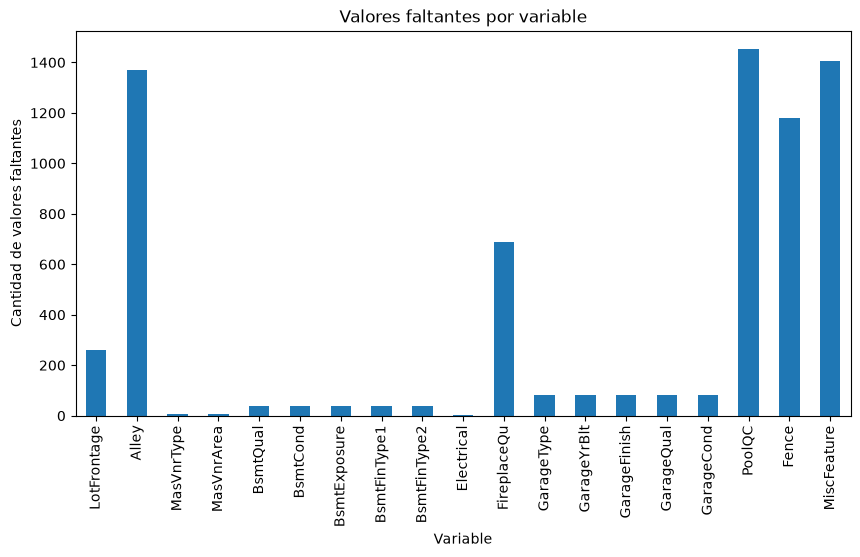

In [19]:
df = pd.read_csv('train.csv', keep_default_na=False, na_values=['NA'])
nulos = df.isnull().sum()
porcentaje = (nulos / len(df)) * 100
tabla_nulos = pd.DataFrame({'valores_faltantes': nulos, 'porcentaje': porcentaje.round(2)})
tabla_nulos = tabla_nulos[tabla_nulos['valores_faltantes'] > 0].sort_values('porcentaje', ascending=False)
tabla_nulos
print (tabla_nulos)
plt.figure(figsize=(10, 5))
nulos[nulos > 0].plot(kind="bar")
plt.title("Valores faltantes por variable")
plt.xlabel("Variable")
plt.ylabel("Cantidad de valores faltantes")
plt.show()

Ahora, se identifican las variables que contienen valores faltantes y se calcula tanto la cantidad de datos ausentes como su porcentaje respecto al total de observaciones. Además, se elimina de la tabla las variables que no presentan valores faltantes y se ordenan las restantes de mayor a menor porcentaje. Este procedimiento permite conocer la magnitud del problema y determinar posteriormente qué estrategia de tratamiento resulta adecuada.
En este dataset se pueden observar valores faltantes en variables como `PoolQC`, `Alley`, `LotFrontage`, `FireplaceQu`, entre otras. 

Por otra parte, se visualiza de manera gráfica la información anterior. Esta opción, facilita la identificación de las variables con mayor concentración de valores faltantes.

El análisis de valores faltantes permitió identificar 19 variables con al menos un valor ausente dentro del conjunto de datos. La cantidad de valores faltantes varía considerablemente entre las variables, desde un solo registro en `Electrical` (0,07 %) hasta 1.453 registros en `PoolQC` (99,52 %).

Las variables con mayor concentración de valores faltantes son **PoolQC (99,52 %)**, **MiscFeature (96,30 %)**, **Alley (93,77 %)** y **Fence (80,75 %)**. También se observa una cantidad considerable de valores ausentes en **FireplaceQu (47,26 %)** y **LotFrontage (17,74 %)**. Por otro lado, las variables relacionadas con garajes presentan un **5,55 %** de valores faltantes, mientras que las variables asociadas al sótano presentan porcentajes cercanos al **2,5 %**.

De acuerdo con información complementaria de `Kaggle` sobre el conjunto de datos, en varias de estas variables la categoría `NA` representa explícitamente la ausencia de la característica, y no necesariamente un dato que haya sido omitido. Por ejemplo, `PoolQC` utiliza `NA` para indicar que no existe piscina, `Fence` para indicar que no existe cerca, `GarageType` y otras variables del garaje para indicar que no existe garaje, mientras que las variables del sótano utilizan NA para indicar que la vivienda no posee sótano.
Por lo tanto, los valores ausentes deben interpretarse de acuerdo con el significado específico de cada variable. En variables que describen características opcionales de las viviendas, la ausencia puede constituir información válida sobre la propiedad. En cambio, variables como `LotFrontage`, que representa la longitud del frente del lote conectado a la calle, requieren un tratamiento diferente, ya que el diccionario de datos no establece que un valor ausente represente la inexistencia de dicha característica.

En consecuencia, el análisis evidencia que no es adecuado aplicar una única estrategia de tratamiento a todos los valores faltantes. Será necesario diferenciar entre los valores que representan la ausencia de una característica y aquellos que corresponden a información realmente no registrada. Esta distinción será considerada posteriormente en la etapa de preparación de los datos.


**Estadísticas descriptivas**

In [ ]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Luego, se generan las estadísticas descriptivas de las variables numéricas del conjunto de datos. Entre los valores obtenidos se encuentran el número de observaciones, media, desviación estándar, valor mínimo, cuartiles y valor máximo. Estas medidas permiten conocer la distribución y escala de las variables, así como detectar posibles valores extremos que posteriormente podrían requerir un análisis adicional.

La mayoría de las variables presentan 1.460 observaciones, correspondientes al total de viviendas, aunque algunas presentan una cantidad inferior debido a la presencia de valores ausentes, como `LotFrontage`, con **1.201 observaciones**, y `MasVnrArea`, con **1.452**.

Se observan diferencias importantes en los rangos de las variables. Por ejemplo, `LotArea` presenta valores entre **1.300 y 215.245 pies cuadrados**, mientras que `SalePrice` presenta valores entre **34.900 y 755.000**. Esto evidencia una considerable variabilidad en las características y precios de las viviendas analizadas.

En particular, la variable objetivo `SalePrice` presenta una `media` de **180.921,20** y una `mediana` de **163.000**. La media superior a la mediana, junto con la diferencia entre el **tercer cuartil (214.000)** y el **valor máximo (755.000)**, sugiere una distribución con asimetría positiva y la posible presencia de valores extremos en el rango superior. Estos valores no se consideran automáticamente errores, por lo que su comportamiento deberá analizarse posteriormente. En términos del dataset, el resultado indica que la mayoría de los precios de venta se concentra en valores bajos y medios, mientras que un grupo reducido de viviendas presenta precios considerablemente más altos.

También se observa que algunas variables relacionadas con características específicas de las viviendas presentan una **mediana igual a cero**, como `PoolArea`, `WoodDeckSF` y `OpenPorchSF`. Esto puede indicar que una proporción importante de las viviendas no posee dichas características. Es importante aclarar que estos valores cero corresponden a valores registrados y deben diferenciarse de los valores ausentes identificados anteriormente.

En conjunto, las estadísticas descriptivas permiten identificar diferencias importantes en escala, dispersión y distribución entre las variables numéricas. Estos resultados servirán como referencia para los análisis posteriores de la distribución de la variable objetivo, la relación entre los predictores y SalePrice, y la identificación de posibles valores extremos.

**Distribución de la variable objetivo**

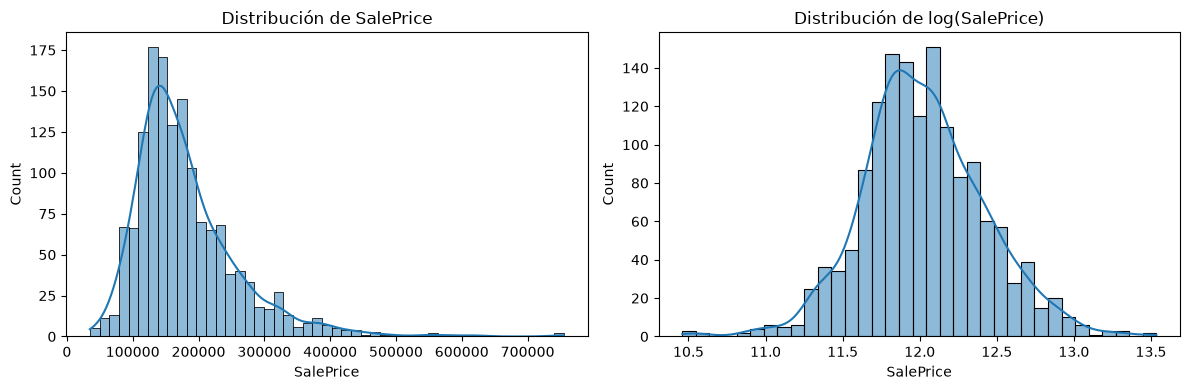

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('Distribución de SalePrice')
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1])
axes[1].set_title('Distribución de log(SalePrice)')
plt.tight_layout()
plt.show()

Este código permite visualizar la distribución de la variable objetivo `SalePrice` mediante dos `histogramas`. El primero muestra los precios de venta en su escala original, mientras que el segundo aplica una transformación logarítmica mediante `log1p()`.

La distribución de `SalePrice` presenta una marcada **asimetría positiva**. La mayoría de los precios de venta se concentra en valores bajos y medios, mientras que un grupo reducido de viviendas presenta precios considerablemente más altos, generando una cola hacia la derecha. Este comportamiento es consistente con las estadísticas descriptivas obtenidas previamente.

Al aplicar una **transformación logarítmica** a `SalePrice`, se observa una distribución más equilibrada y cercana a la simetría. La transformación reduce la influencia de los valores elevados y permite observar una concentración más uniforme de los datos. Este resultado indica que una transformación logarítmica podría ser considerada posteriormente como parte de la preparación de los datos, aunque su aplicación definitiva dependerá del comportamiento y desempeño del modelo.

**Análisis de las relaciones entre las variables predictoras y con la variable objetivo**

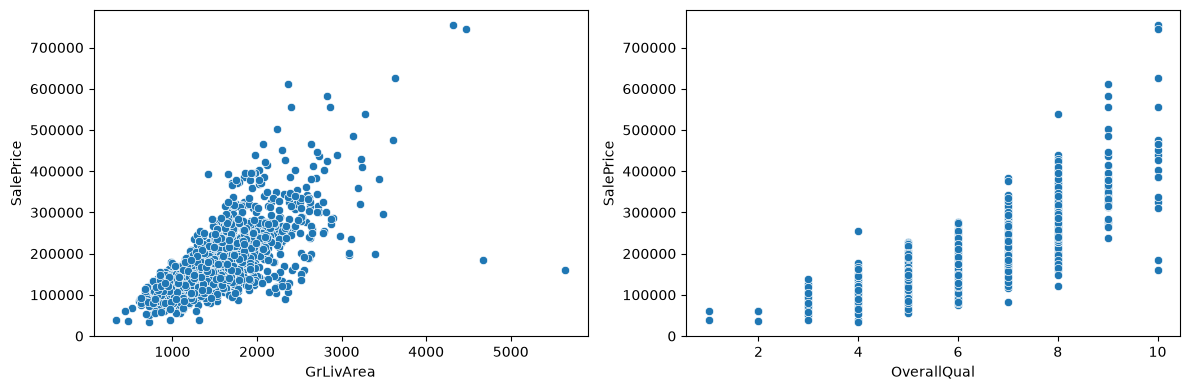

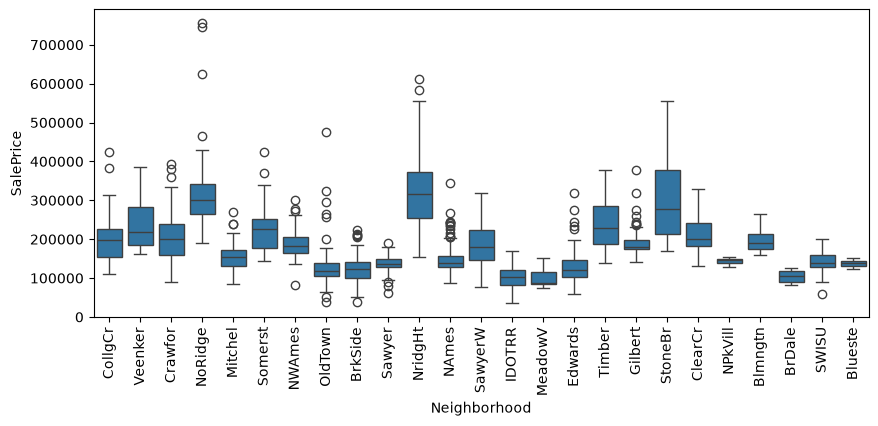

In [7]:
# Numéricas vs SalePrice
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, ax=axes[0])
sns.scatterplot(x='OverallQual', y='SalePrice', data=df, ax=axes[1])
plt.tight_layout()
plt.show()

# Categórica vs SalePrice
plt.figure(figsize=(10, 4))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=90)
plt.show()

Estos gráficos permiten analizar visualmente la relación entre algunas variables predictoras numéricas y la variable objetivo `SalePrice`. 

En el primer resultado, se observa una relación positiva entre `GrLivArea`(superficie habitable sobre el nivel del suelo (pies cuadrados)) y `SalePrice`. En términos generales, las viviendas con mayor área habitable tienden a presentar precios de venta más elevados. Sin embargo, la dispersión de los puntos indica que el área habitable por sí sola no explica completamente el precio de las viviendas. 

Por otra parte, en la segunda gráfica se puede concluir que existe una relación positiva entre `OverallQual` (calidad general del material y del acabado) y `SalePrice`. A medida que aumenta la calificación general de la vivienda, se observa una tendencia hacia precios de venta más elevados. Esta relación parece ser más marcada que la observada entre `GrLivArea` y `SalePrice`, lo que indica que la calidad general de la vivienda podría ser una variable relevante para explicar las diferencias en el precio.

Por último, el análisis de `Neighborhood` (ubicaciones físicas dentro de los límites de la ciudad de Ames) muestra diferencias en la distribución de `SalePrice` entre los distintos barrios. Se observan variaciones tanto en las medianas como en la dispersión de los precios, lo que indica que la ubicación de la vivienda está asociada con diferencias importantes en su valor de venta. Además, se identifican posibles valores extremos en algunos barrios, los cuales deberán analizarse posteriormente.

Por lo tanto, las relaciones entre los predictores y la variable objetivo evidencian que características como el `área habitable (GrLivArea)`, `la calidad general de la vivienda (OverallQual)` y el `barrio (Neighborhood)` presentan asociaciones con `SalePrice`. Las variables numéricas muestran tendencias positivas, mientras que la variable categórica presenta diferencias en la distribución de precios entre sus categorías. Estos resultados indican que el precio de venta está relacionado con múltiples características de las viviendas, por lo que resulta pertinente considerar diferentes tipos de predictores en el modelo de regresión.

**Análisis de correlación entre variables numéricas.**

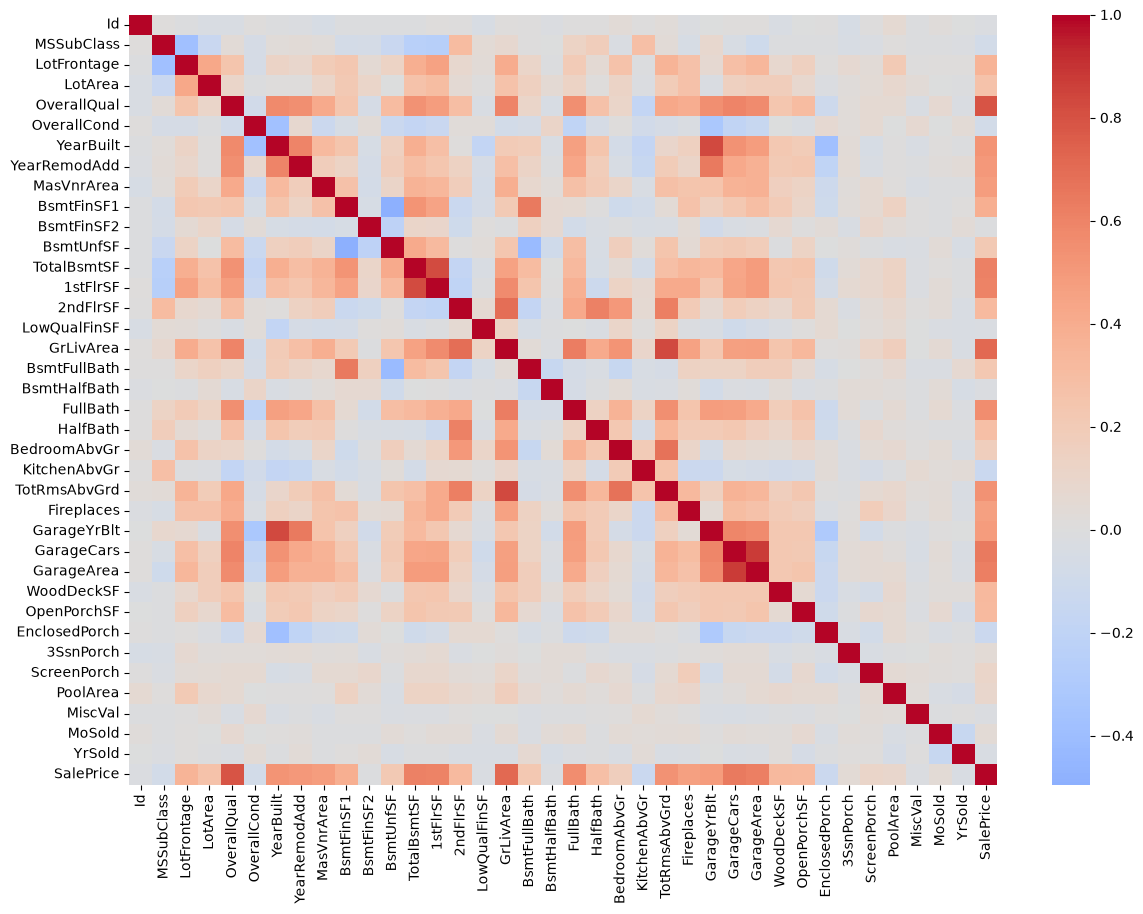

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

In [8]:
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()
# Top 10 variables más correlacionadas con SalePrice
corr['SalePrice'].sort_values(ascending=False).head(11)

In [9]:
correlacion = df.select_dtypes(include="number").corr()
correlacion

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


Se realizó un análisis de correlación de las variables numéricas mediante el coeficiente de correlación de Pearson, con el propósito de identificar relaciones lineales entre los predictores y la variable objetivo, con el propósito de identificar relaciones lineales entre los predictores y la variable objetivo `SalePrice`, así como posibles relaciones fuertes entre las propias variables predictoras.

Los resultados muestran que `OverallQual` presenta la mayor correlación positiva con `SalePrice` (0,791), seguida de `GrLivArea` (0,709), `GarageCars` (0,640), `GarageArea` (0,623), `TotalBsmtSFTotalBsmtSF` (0,614) y `1stFlrSF` (0,606). Esto indica que estas variables presentan asociaciones lineales positivas con el precio de venta, es decir, valores mayores de estas características tienden a estar relacionados con precios de venta más elevados.

También se identifican variables con correlaciones cercanas a cero, como `Id` (-0,022), `MiscVal` (-0,021) y `MoSold` (0,046), lo que indica una asociación lineal débil con `SalePrice`.

Adicionalmente, el mapa de correlación permite observar relaciones elevadas entre algunas variables predictoras, como las relacionadas con las características y dimensiones del garaje. Estas relaciones pueden indicar cierta redundancia entre variables y serán consideradas posteriormente durante la preparación y construcción del modelo.

En general, el análisis de correlación permite identificar variables que presentan una asociación lineal importante con la variable objetivo y posibles relaciones entre predictores. Sin embargo, la correlación no implica causalidad ni determina por sí sola qué variables deben incluirse o eliminarse del modelo. Estas decisiones serán evaluadas en las etapas posteriores del proyecto.

**Mapa de valores faltantes**

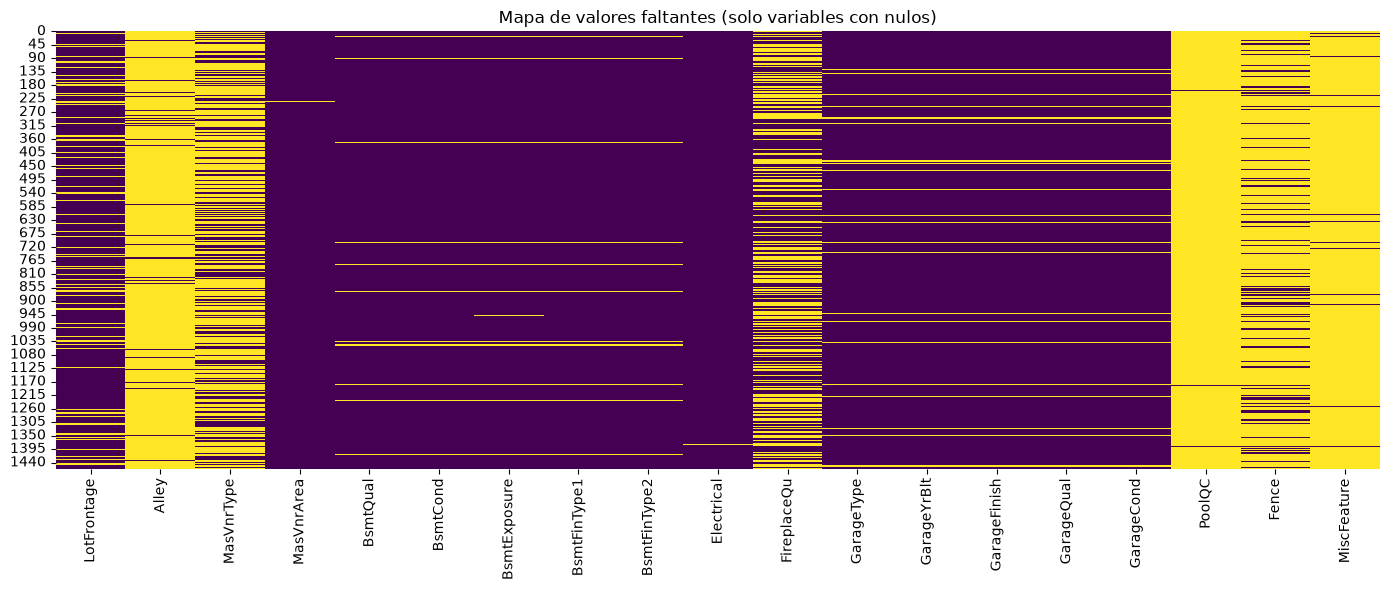

In [10]:
cols_con_nulos = df.columns[df.isnull().any()].tolist()
plt.figure(figsize=(14, 6))
sns.heatmap(df[cols_con_nulos].isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de valores faltantes (solo variables con nulos)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

La visualización de los valores faltantes permite identificar patrones en su distribución entre las viviendas. Se observa que algunas variables presentan una alta concentración de valores faltantes, como `PoolQC`, `MiscFeature`, `Alley`y `Fence`, mientras que otras presentan una cantidad reducida. 

Además, se identifican patrones similares entre variables que describen una misma característica de la vivienda, especialmente en los grupos relacionados con el garaje y el sótano, donde los valores faltantes tienden a aparecer en las mismas observaciones. Esto sugiere que, en determinados casos, la ausencia de información puede estar relacionada con la ausencia de la característica correspondiente. 

Por otro lado, variables como `LotFrontage` presentan un patrón diferente y requieren un análisis particular. Por esta razón, no resulta adecuado aplicar una única estrategia de tratamiento a todos los valores faltantes; su manejo se definirá posteriormente de acuerdo con el significado y comportamiento de cada variable.

**Cantidad de observaciones por vecindario**

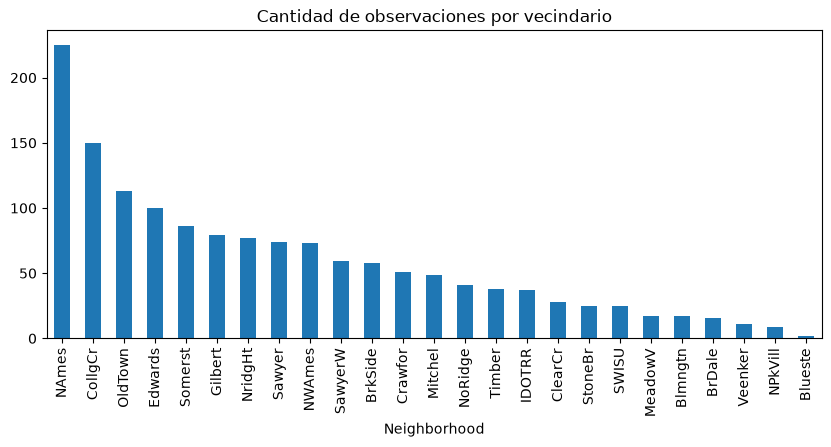

In [11]:
plt.figure(figsize=(10, 4))
df['Neighborhood'].value_counts().plot(kind='bar')
plt.title('Cantidad de observaciones por vecindario')
plt.xticks(rotation=90)
plt.show()

La distribución de observaciones por `Neighborhood` muestra que las categorías de esta variable no presentan la misma cantidad de viviendas. Algunos vecindarios, como `NAmes`, `CollgCr` y `OldTown`, concentran una mayor cantidad de observaciones, mientras que otros, como `BrDale`, `NPkVill` y `Blueste`, presentan una representación considerablemente menor. Esta distribución desigual se tendrá en cuenta al analizar la relación entre el vecindario y `SalePrice`, especialmente en aquellas categorías con un número reducido de observaciones. 